# STEP 14. 가로 구조 통제변수: axial map + segment angular

**목적**: 다음 단계 회귀(공원 군집 ↔ 상업 활동)에서 "큰길에 있어서 장사가 잘된다"는 효과를 통제할 변수를 만든다. 상점이 접한 가로의 Space Syntax 값을 두 계열로 준비한다.

| 계열 | 무엇 | 계산 |
|---|---|---|
| **Axial** (위상) | 직선(axial line) 그래프의 Connectivity, Integration(HH) Rn·R3·R5·R7, Choice | 이 노트북 (Python, igraph) |
| **Segment angular** | 각도 choice·farness 기반 NACH 유사·NAIN 유사, 400/800/1600/3200 m | Cityseer (STEP 5 결과 + 400 m 추가) |

**Axial line 만드는 법** (가로 중심선에서 유도한 근사)
- 진짜 axial map(열린 공간을 덮는 최소 직선 집합)은 NYC 규모에서 만들 수 없다. 대신 가로 중심선(C 망)에서 "시선이 이어지는 직선"을 뽑는다.
  1. 교차점마다 가장 곧게 이어지는 세그먼트끼리 잇는다(STEP 5 stroke와 같은 규칙, 편차 < 30°).
  2. 이은 선을 Douglas–Peucker로 단순화한다. 허용 횡편차 `AXIAL_TOL`(10 m ≈ 60 ft 가로 폭의 절반) 안에서 직선으로 볼 수 있는 조각 하나가 axial line 하나다.
  3. 두 선은 **보행망의 같은 교차점을 지나면** 연결된다. 기하학적으로 겹치기만 하는 다리·터널은 연결되지 않는다.
- 지표는 Hillier & Hanson(1984)의 고전 정의 그대로다: Mean Depth → RA → RRA(D-value 보정) → Integration(HH) = 1/RRA.

**검증**: 브루클린 파일럿 구역의 선을 R 패키지 `alcyon`(depthmapX의 계산 엔진 sala)에 넣어 수치를 대조한다. alcyon은 검증에만 쓰고, 본 계산은 Python이다.

**주의**
- 이 값들은 공원 네트워크 정의(D·N1·N2·N3)에 쓰지 않는다. 회귀의 통제변수 전용이다.
- 중심선에서 유도한 근사이므로 손으로 그린 axial map과 선 집합이 다르다. 중앙분리대가 있는 대로는 중심선이 둘이라 선도 둘이 된다.
- 보행망이 끊긴 곳(스태튼아일랜드, 뉴저지)은 별도 시스템이다. Integration(HH)은 D-value로 시스템 크기를 보정한 값이다.

**출력**
- `Data/derived/network/axial_*`: 선, 선-세그먼트 대응, 지표 (지역 무관)
- `Data/derived/{AREA}/segment_controls.parquet`: 세그먼트별 통제변수
- `outputs/{AREA}/controls/`: `axial_lines.gpkg`, `cluster_street_controls.csv`, `park_street_controls.csv`, `axial_validation.csv`, `control_correlations.csv`, 지도, `README.md`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 연구 개요: 군집 구성 공원 주변 100 m = 상업 영역

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
import logging
import shutil
import subprocess
import shapely
import igraph as ig
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from scipy.stats import spearmanr, pearsonr
from cityseer.network import CityNetwork

logging.getLogger("cityseer").setLevel(logging.WARNING)
CN_DIR = NET_DIR / "cityseer"
CT_DIR = OUT_DIR / "controls"
CT_DIR.mkdir(parents=True, exist_ok=True)
V = PRIMARY

# STEP 14 파라미터
AXIAL_DEFL = STROKE_ANGLE        # 교차점에서 이어 붙일 최대 편차 (°)
AXIAL_TOL = 10                   # 직선으로 볼 허용 횡편차 (m)
AXIAL_TOL_GRID = [5, 10, 15]
AXIAL_RADII = [3, 5, 7]          # 국지 반경 (위상 단계 수). 전역은 n
LOCAL_RADIUS = 400               # 추가로 계산하는 각도 중심성 반경 (m)
ANG_RADII = [LOCAL_RADIUS] + N2_RADII
FRONT_KINDS = ["street"]         # 상점이 접하는 가로로 보는 세그먼트 종류
PILOT_HALF = 2000                # alcyon 검증 구역: 중심에서 ±2 km

segs = gpd.read_parquet(NET_DIR / f"segments_{V}.parquet", columns=["seg_id", "kind", "length", "geometry"]).reset_index(drop=True)
boroughs = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough")
AREA = boroughs.loc[AREA_BOROUGHS].union_all()
parks = gpd.read_parquet(NET_DIR / "parks.parquet")
print(f"{len(segs):,} segments ({V})")

495,627 segments (C)


## 14-1. Axial line 생성
- `stroke_chains`: 교차점마다 편차가 작은 짝부터 짝지어(every-best-fit) 세그먼트를 순서 있는 체인으로 잇는다. STEP 5 `build_strokes`와 같은 규칙이고, 여기서는 좌표 순서까지 돌려준다.
- `axial_lines`: 체인 좌표열을 Douglas–Peucker(`tol`)로 단순화한다. 단순화된 각 직선 조각이 axial line이다.
  - 고리 체인은 시작점에서 가장 먼 꼭짓점에서 한 번 끊어, 길이 0인 선이 생기지 않게 한다.
  - 양 끝점이 같은 선(같은 두 교차점을 잇는 중복 세그먼트)은 하나로 합친다.
- 연결: 같은 교차점(세그먼트 끝점)을 지나는 선끼리, 그리고 한 체인에서 이어지는 조각끼리.

In [3]:
def end_vectors(geoms, probe=15.0):
    L = shapely.length(geoms)
    p0 = shapely.get_point(geoms, 0)
    p1 = shapely.get_point(geoms, -1)
    q0 = shapely.line_interpolate_point(geoms, np.minimum(probe, L / 2))
    q1 = shapely.line_interpolate_point(geoms, np.maximum(L - probe, L / 2))
    v0 = np.c_[shapely.get_x(q0) - shapely.get_x(p0), shapely.get_y(q0) - shapely.get_y(p0)]
    v1 = np.c_[shapely.get_x(q1) - shapely.get_x(p1), shapely.get_y(q1) - shapely.get_y(p1)]
    k0 = list(zip(np.round(shapely.get_x(p0), 1), np.round(shapely.get_y(p0), 1)))
    k1 = list(zip(np.round(shapely.get_x(p1), 1), np.round(shapely.get_y(p1), 1)))
    return k0, k1, v0, v1


def stroke_chains(geoms, max_defl):
    """반환: 체인 목록 [(세그먼트, 뒤집힘), ...], 세그먼트 시작·끝 노드 id"""
    n = len(geoms)
    k0, k1, v0, v1 = end_vectors(geoms)
    node = pd.factorize(pd.Series(k0 + k1))[0]      # 끝점 e (= seg + side·n)의 노드 id
    vec = np.r_[v0, v1]
    norm = np.linalg.norm(vec, axis=1)
    norm[norm == 0] = 1
    vec = vec / norm[:, None]
    seg_arr = np.r_[np.arange(n), np.arange(n)]
    side_arr = np.r_[np.zeros(n, int), np.ones(n, int)]
    link = {}  # (seg, side) -> (seg, side)
    grp = pd.Series(np.arange(2 * n)).groupby(node).apply(list)
    grp = grp[grp.str.len() >= 2]
    for es in grp.values:
        cand = []
        for x in range(len(es)):
            for y in range(x + 1, len(es)):
                a, b = es[x], es[y]
                if seg_arr[a] == seg_arr[b]:
                    continue
                defl = 180 - np.degrees(np.arccos(np.clip(np.dot(vec[a], vec[b]), -1, 1)))
                if defl < max_defl:
                    cand.append((defl, a, b))
        used = set()
        for defl, a, b in sorted(cand):
            if a in used or b in used:
                continue
            used.update((a, b))
            link[(seg_arr[a], side_arr[a])] = (seg_arr[b], side_arr[b])
            link[(seg_arr[b], side_arr[b])] = (seg_arr[a], side_arr[a])
    chains, seen = [], np.zeros(n, bool)

    def walk(start, entry):
        ch, cur = [], start
        while not seen[cur]:
            seen[cur] = True
            ch.append((cur, entry == 1))
            nxt = link.get((cur, 1 - entry))
            if nxt is None:
                break
            cur, entry = nxt
        return ch

    for s in range(n):            # 열린 끝에서 시작
        if seen[s]:
            continue
        if (s, 0) not in link:
            chains.append(walk(s, 0))
        elif (s, 1) not in link:
            chains.append(walk(s, 1))
    for s in range(n):            # 남은 것은 고리
        if not seen[s]:
            chains.append(walk(s, 0))
    return chains, node[:n], node[n:]


def axial_lines(geoms, chains, n0, n1, tol):
    """반환: lines(선 양 끝 좌표), seg_line(세그먼트-선 겹침 길이), E(선 그래프 엣지, 무방향·중복 없음)"""
    coords = shapely.get_coordinates(geoms)
    npts = shapely.get_num_points(geoms)
    first = np.r_[0, np.cumsum(npts)[:-1]]
    XY, ND, SG, IV = [], [], [], []      # 체인별 좌표, 꼭짓점 노드 id(-1 = 세그먼트 내부), 구간별 세그먼트, 단순화 구간
    for ci, ch in enumerate(chains):
        xs, nd, sg = [], [], []
        for k, (s, rev) in enumerate(ch):
            c = coords[first[s]:first[s] + npts[s]]
            a, b = (n1[s], n0[s]) if rev else (n0[s], n1[s])
            if rev:
                c = c[::-1]
            v = np.full(len(c), -1)
            v[0], v[-1] = a, b
            if k:                        # 이음 꼭짓점 중복 제거
                c, v = c[1:], v[1:]
            xs.append(c)
            nd.append(v)
            sg.append(np.full(len(c) - (0 if k else 1), s))
        xy, nd = np.vstack(xs), np.concatenate(nd)
        XY.append(xy)
        ND.append(nd)
        SG.append(np.concatenate(sg))
        last = len(xy) - 1
        f = int(np.argmax(np.hypot(*(xy - xy[0]).T))) if nd[0] == nd[-1] and last >= 2 else 0
        IV.extend([(ci, 0, f), (ci, f, last)] if 0 < f < last else [(ci, 0, last)])
    parts = [XY[ci][a:b + 1] for ci, a, b in IV]
    simp = shapely.simplify(shapely.linestrings(np.vstack(parts), indices=np.repeat(np.arange(len(parts)), [len(p) for p in parts])),
                            tol, preserve_topology=False)
    L_rows, SL_rows, LN_rows, CE = [], [], [], []
    lid, prev_chain = 0, -1
    for (ci, a0, b0), g in zip(IV, simp):
        xy, nd, sg = XY[ci], ND[ci], SG[ci]
        idx, p = [], a0
        for q in shapely.get_coordinates(g):      # 단순화 꼭짓점 → 원래 인덱스
            while p < b0 and not (xy[p, 0] == q[0] and xy[p, 1] == q[1]):
                p += 1
            idx.append(p)
        idx[0], idx[-1] = a0, b0
        d = np.hypot(*np.diff(xy, axis=0).T)
        for a, b in zip(idx[:-1], idx[1:]):
            if b <= a:
                continue
            L_rows.append((lid, ci, xy[a, 0], xy[a, 1], xy[b, 0], xy[b, 1]))
            seg_ids, inv = np.unique(sg[a:b], return_inverse=True)
            SL_rows.extend(zip(seg_ids.tolist(), [lid] * len(seg_ids), np.bincount(inv, weights=d[a:b]).tolist()))
            nn = nd[a:b + 1]
            LN_rows.extend((lid, int(x)) for x in np.unique(nn[nn >= 0]))
            if prev_chain == ci:         # 같은 체인의 이어지는 조각
                CE.append((lid - 1, lid))
            prev_chain = ci
            lid += 1
    lines = pd.DataFrame(L_rows, columns=["line", "chain", "x0", "y0", "x1", "y1"])
    # 양 끝점이 같은 선은 하나로 합친다
    p0, p1 = lines[["x0", "y0"]].values.round(1), lines[["x1", "y1"]].values.round(1)
    swap = (p0[:, 0] > p1[:, 0]) | ((p0[:, 0] == p1[:, 0]) & (p0[:, 1] > p1[:, 1]))
    lo, hi = np.where(swap[:, None], p1, p0), np.where(swap[:, None], p0, p1)
    new = pd.factorize(pd.MultiIndex.from_arrays([lo[:, 0], lo[:, 1], hi[:, 0], hi[:, 1]]))[0]
    lines["line"] = new
    lines = lines.drop_duplicates("line").sort_values("line").reset_index(drop=True)
    seg_line = pd.DataFrame(SL_rows, columns=["seg", "line", "length"])
    seg_line["line"] = new[seg_line.line.values]
    seg_line = seg_line.groupby(["seg", "line"], as_index=False).length.sum()
    line_node = pd.DataFrame(LN_rows, columns=["line", "node"])
    line_node["line"] = new[line_node.line.values]
    line_node = line_node.drop_duplicates()
    m = line_node.merge(line_node, on="node")
    m = m[m.line_x < m.line_y]
    ce = new[np.array(CE, dtype=int).reshape(-1, 2)]
    ce = np.sort(ce[ce[:, 0] != ce[:, 1]], axis=1)
    E = np.unique(np.vstack([m[["line_x", "line_y"]].values, ce]), axis=0)
    return lines, seg_line, E


def build_axial(tol):
    fl, fs, fe = (NET_DIR / f"axial_{k}_{V}_t{tol}.{ext}" for k, ext in [("lines", "parquet"), ("segline", "parquet"), ("edges", "npy")])
    if fl.exists() and fs.exists() and fe.exists():
        return pd.read_parquet(fl), pd.read_parquet(fs), np.load(fe)
    lines, seg_line, E = axial_lines(segs.geometry.values, CHAINS, N0, N1, tol)
    lines["chord_m"] = np.hypot(lines.x1 - lines.x0, lines.y1 - lines.y0)
    by = seg_line.groupby("line")
    lines["path_m"] = by.length.sum().reindex(lines.line).values
    lines["n_seg"] = by.seg.nunique().reindex(lines.line).values
    kind_len = seg_line.assign(kind=segs.kind.values[seg_line.seg.values]).groupby(["line", "kind"]).length.sum().unstack(fill_value=0)
    lines["main_kind"] = kind_len.idxmax(axis=1).reindex(lines.line).values
    lines.to_parquet(fl)
    seg_line.to_parquet(fs)
    np.save(fe, E)
    return lines, seg_line, E


t0 = time.time()
CHAINS, N0, N1 = stroke_chains(segs.geometry.values, AXIAL_DEFL)
print(f"{len(CHAINS):,} chains (deflection < {AXIAL_DEFL}°), longest {max(map(len, CHAINS))} segments  ({time.time() - t0:.0f}s)")
AX = {}
rows = []
for tol in AXIAL_TOL_GRID:
    lines, seg_line, E = build_axial(tol)
    AX[tol] = (lines, seg_line, E)
    deg = np.bincount(E.ravel(), minlength=len(lines))
    rows.append({"tol_m": tol, "lines": len(lines), "links": len(E), "segments per line": round(len(segs) / len(lines), 2),
                 "mean connectivity": round(deg.mean(), 2), "max connectivity": int(deg.max()),
                 "median length m": round(lines.chord_m.median()), "mean length m": round(lines.chord_m.mean()),
                 "max length m": round(lines.chord_m.max()), "zero-length lines": int((lines.chord_m < 0.5).sum())})
    assert seg_line.seg.nunique() == len(segs), "모든 세그먼트가 선에 속해야 함"
    assert np.isclose(seg_line.length.sum(), shapely.length(segs.geometry.values).sum(), rtol=1e-6), "선-세그먼트 겹침 길이 합 = 네트워크 연장"
pd.DataFrame(rows).set_index("tol_m")

123,433 chains (deflection < 30°), longest 660 segments  (6s)


,lines,links,segments per line,mean connectivity,max connectivity,median length m,mean length m,max length m,zero-length lines
tol_m,,,,,,,,,
5,218783,334708,2.27,3.06,189,38,94,11763,16
10,181920,291722,2.72,3.21,239,45,112,14460,16
15,165959,272997,2.99,3.29,238,49,122,14460,16


## 14-2. Axial 지표 (고전 정의, igraph)
선 그래프(노드 = axial line, 엣지 = 교차)의 위상 깊이로 계산한다.
- **Connectivity**: 직접 교차하는 선의 수
- **Mean Depth** MD = 총 깊이 / (k − 1), k = 반경 안 선의 수(자신 포함)
- **RA** = 2(MD − 1)/(k − 2), **RRA** = RA / D_k, **Integration(HH)** = 1/RRA
  - D_k = 2{k[log₂((k + 2)/3) − 1] + 1} / ((k − 1)(k − 2))
- 반경 n(전역)은 연결된 시스템 전체, 반경 r(국지)은 r 단계 안의 선만 본다.
- **Choice**: 최단 위상 경로가 지나가는 횟수. 순서쌍 기준이라 무방향 betweenness의 2배이고, depthmapX의 Choice와 같은 척도다.

Rn 깊이는 igraph closeness(= 1/MD), 국지 깊이는 단계별 이웃 수에서 구한다.

In [4]:
def dvalue(k):
    return 2 * (k * (np.log2((k + 2) / 3) - 1) + 1) / ((k - 1) * (k - 2))


def integration_hh(td, k):
    with np.errstate(all="ignore"):
        md = td / (k - 1)
        ra = 2 * (md - 1) / (k - 2)
        return np.where((k > 2) & (ra > 0), dvalue(k) / ra, np.nan), md


def _chunked(fn, n, label, parts=20):
    out, t0 = np.zeros(n), time.time()
    for q, chunk in enumerate(np.array_split(np.arange(n), parts)):
        out += fn(chunk.tolist())
        if (q + 1) % 5 == 0:
            print(f"   {label}: {q + 1}/{parts}  ({time.time() - t0:.0f}s)")
    return out


def axial_measures(n, E, radii=AXIAL_RADII, choice=True, label=""):
    g = ig.Graph(n=int(n), edges=np.asarray(E).tolist(), directed=False)
    out = pd.DataFrame({"connectivity": g.degree()})
    comp = np.array(g.connected_components().membership)
    k = np.bincount(comp)[comp].astype(float)
    out["system"], out["node_count"] = comp, k

    def clo(vs):
        r = np.zeros(n)
        r[vs] = g.closeness(vertices=vs)
        return r

    cl = _chunked(clo, n, f"{label} depth Rn")
    with np.errstate(all="ignore"):
        out["int_n"], out["md_n"] = integration_hh((k - 1) / cl, k)
    N = {0: np.ones(n)}
    for d in range(1, max(radii) + 1):
        N[d] = np.array(g.neighborhood_size(order=d), dtype=float)
    for r in radii:
        td = sum(d * (N[d] - N[d - 1]) for d in range(1, r + 1))
        out[f"int_r{r}"], out[f"md_r{r}"] = integration_hh(td, N[r])
        out[f"node_count_r{r}"] = N[r]
    if choice:
        # 출발 묶음별 betweenness의 합이 전체의 몇 배인지 작은 격자에서 확인해 맞춘다
        t = ig.Graph.Lattice([5, 5], circular=False)
        ratio = np.sum([t.betweenness(sources=c.tolist(), directed=False) for c in np.array_split(np.arange(25), 3)], axis=0)[12] \
            / t.betweenness(directed=False)[12]
        bt = _chunked(lambda vs: np.array(g.betweenness(sources=vs, directed=False)), n, f"{label} choice") / ratio
        out["choice"] = 2 * bt
        with np.errstate(all="ignore"):
            out["choice_norm"] = np.where(k > 2, out.choice / ((k - 1) * (k - 2) / 2), np.nan)
        out["choice_log"] = np.log10(out.choice + 1)
    return out


def measures_for(tol, choice):
    f = NET_DIR / f"axial_measures_{V}_t{tol}.parquet"
    if f.exists():
        m = pd.read_parquet(f)
        if not choice or "choice" in m.columns:
            return m
    t0 = time.time()
    lines, _, E = AX[tol]
    m = axial_measures(len(lines), E, choice=choice, label=f"tol {tol}")
    m.to_parquet(f)
    print(f"tol {tol}: measures on {len(lines):,} lines in {time.time() - t0:.0f}s")
    return m


MEAS = {AXIAL_TOL: measures_for(AXIAL_TOL, choice=True)}
m = MEAS[AXIAL_TOL]
sysz = m.groupby("system").size().sort_values(ascending=False)
print(f"systems: {len(sysz):,}; largest {sysz.iloc[:4].tolist()} lines ({sysz.iloc[0] / len(m):.0%} in the largest)")
m[["connectivity", "node_count", "md_n", "int_n", "int_r3", "int_r5", "int_r7", "choice_log"]].describe().round(3)

   tol 10 depth Rn: 5/20  (33s)


   tol 10 depth Rn: 10/20  (111s)


   tol 10 depth Rn: 15/20  (204s)


   tol 10 depth Rn: 20/20  (299s)


   tol 10 choice: 5/20  (52s)


   tol 10 choice: 10/20  (178s)


   tol 10 choice: 15/20  (331s)


   tol 10 choice: 20/20  (486s)
tol 10: measures on 181,920 lines in 794s
systems: 3,015; largest [122350, 24833, 14929, 4085] lines (67% in the largest)


,connectivity,node_count,md_n,int_n,int_r3,int_r5,int_r7,choice_log
count,181920.000,181920.000,179939.000,178921.000,178921.000,178921.000,178921.000,181920.000
mean,3.207,87058.600,28.974,0.511,1.801,1.587,1.418,3.484
std,3.627,50906.954,10.669,0.177,0.758,0.545,0.428,2.458
min,0.000,1.000,1.000,0.141,0.211,0.211,0.211,0.000
25%,2.000,24833.000,24.067,0.416,1.255,1.182,1.111,0.477
50%,2.000,122350.000,27.372,0.511,1.682,1.544,1.409,4.465
75%,3.000,122350.000,34.099,0.576,2.249,1.953,1.708,5.469
max,239.000,122350.000,84.783,11.000,11.000,11.000,11.000,9.576


## 14-3. 검증: alcyon(depthmapX 엔진)과 대조
브루클린 포트그린 주변 4 km × 4 km 구역의 선을 `alcyon`에 넣는다. alcyon은 선이 **기하학적으로 교차하면** 연결로 보므로, 선을 양쪽으로 `AXIAL_TOL + 2 m` 늘려서 넘긴다(단순화로 끝점이 교차점에서 최대 `AXIAL_TOL`만큼 벗어날 수 있어서다).

두 가지를 확인한다.
- **(A) 수식**: alcyon이 만든 연결 그래프를 그대로 받아 이 노트북의 함수로 계산한 값이 alcyon 값과 같은가.
- **(B) 연결 규칙**: 교차점 기준 연결(이 노트북)과 기하 교차 연결(alcyon)이 얼마나 다른가.

Rscript나 alcyon이 없으면 이 절은 건너뛴다.

In [5]:
R_SCRIPT = '''suppressMessages(library(alcyon))
args <- commandArgs(trailingOnly = TRUE)
ln <- st_read(args[1], quiet = TRUE)
st_geometry(ln) <- "geometry"
g <- as(ln[, "line"], "AxialShapeGraph")
res <- allToAllTraverse(g, traversalType = TraversalType$Topological, radii = c("n", "3"),
                        radiusTraversalType = TraversalType$Topological, includeBetweenness = TRUE)
write.csv(st_drop_geometry(as(res, "sf")), args[2], row.names = FALSE)
write.csv(as.data.frame(connections(res)), args[3], row.names = FALSE)
'''
lines, seg_line, E = AX[AXIAL_TOL]
fg = parks[parks["name"].astype(str).str.contains("Fort Greene Park")]
ctr = fg.geometry.iloc[0].centroid if len(fg) else boroughs.loc["B"].geometry.centroid
PILOT_WIN = shapely.box(ctr.x - PILOT_HALF, ctr.y - PILOT_HALF, ctr.x + PILOT_HALF, ctr.y + PILOT_HALF)
P0, P1 = lines[["x0", "y0"]].values, lines[["x1", "y1"]].values
CHORD = shapely.linestrings(np.stack([P0, P1], axis=1))
sel = np.where(shapely.intersects(CHORD, PILOT_WIN) & (lines.chord_m.values >= 0.5))[0]
u = (P1 - P0) / np.maximum(lines.chord_m.values, 1e-9)[:, None]
ext = AXIAL_TOL + 2.0
pilot = gpd.GeoDataFrame({"line": lines.line.values[sel]},
                         geometry=shapely.linestrings(np.stack([P0 - u * ext, P1 + u * ext], axis=1))[sel], crs=CRS)
VAL = None
if shutil.which("Rscript"):
    (CT_DIR / "alcyon_pilot.R").write_text(R_SCRIPT)
    tmp = AREA_DIR / "_alcyon"
    tmp.mkdir(exist_ok=True)
    pilot.to_file(tmp / "pilot_lines.gpkg", driver="GPKG")
    run = subprocess.run(["Rscript", str(CT_DIR / "alcyon_pilot.R"), str(tmp / "pilot_lines.gpkg"), str(tmp / "alcyon.csv"), str(tmp / "conn.csv")],
                         capture_output=True, text=True)
    if run.returncode == 0:
        VAL = pd.read_csv(tmp / "alcyon.csv"), pd.read_csv(tmp / "conn.csv")
    else:
        print("alcyon 실행 실패 → 검증 건너뜀:\n", run.stderr[-600:])
else:
    print("Rscript 없음 → 검증 건너뜀")
print(f"pilot: {len(pilot):,} lines")

INFO:pyogrio._io:Created 2,556 records


pilot: 2,556 lines


In [6]:
if VAL is not None:
    alc, con = VAL
    assert len(alc) == len(pilot) and (alc["line"].values == pilot.line.values).all(), "alcyon이 선을 그대로 받아야 함"
    E_geo = np.unique(np.sort(con[["from", "to"]].values, axis=1), axis=0)
    mine = axial_measures(len(alc), E_geo, radii=[3], label="pilot (alcyon graph)")
    pairs = [("Connectivity", "connectivity", "Connectivity"), ("Node Count", "node_count", "Node Count"),
             ("Mean Depth", "md_n", "Mean Depth"), ("Integration [HH]", "int_n", "Integration [HH]"),
             ("Node Count R3", "node_count_r3", "Node Count R3"), ("Mean Depth R3", "md_r3", "Mean Depth R3"),
             ("Integration [HH] R3", "int_r3", "Integration [HH] R3"), ("Choice", "choice", "Choice")]
    rows = []
    for name, mc, ac in pairs:
        x, y = mine[mc].values.astype(float), alc[ac].values.astype(float)
        ok = np.isfinite(x) & np.isfinite(y) & (y >= 0)      # alcyon은 정의되지 않는 값을 -1로 둔다
        rows.append({"check": "A. same graph", "measure": name, "n": int(ok.sum()), "max abs diff": np.abs(x[ok] - y[ok]).max(),
                     "max rel diff": (np.abs(x[ok] - y[ok]) / np.maximum(np.abs(y[ok]), 1e-12)).max(),
                     "pearson": pearsonr(x[ok], y[ok])[0], "spearman": spearmanr(x[ok], y[ok])[0]})
    A = pd.DataFrame(rows)
    exact = A[A.measure != "Choice"]
    assert (exact["max rel diff"] < 1e-4).all(), "Connectivity·Mean Depth·Integration은 alcyon과 같아야 함"
    assert A.loc[A.measure == "Choice", "pearson"].iloc[0] > 0.99
    # (B) 연결 규칙 비교: 교차점 기준(이 노트북) vs 기하 교차(alcyon)
    pos = pd.Series(np.arange(len(sel)), index=lines.line.values[sel])
    keep = np.isin(E[:, 0], pos.index) & np.isin(E[:, 1], pos.index)
    E_top = np.c_[pos.loc[E[keep, 0]].values, pos.loc[E[keep, 1]].values]
    E_top = np.unique(np.sort(E_top, axis=1), axis=0)
    s_top, s_geo = set(map(tuple, E_top)), set(map(tuple, E_geo))
    topo = axial_measures(len(alc), E_top, radii=[3], choice=False, label="pilot (network graph)")
    big = (topo.node_count == topo.node_count.max()).values & (mine.node_count == mine.node_count.max()).values
    B = pd.DataFrame([{"check": "B. connection rule", "measure": mname, "n": int((big & np.isfinite(topo[c]) & np.isfinite(mine[c])).sum()),
                       "pearson": topo.loc[big, c].corr(mine.loc[big, c]), "spearman": topo.loc[big, c].corr(mine.loc[big, c], method="spearman")}
                      for mname, c in [("Connectivity", "connectivity"), ("Integration [HH]", "int_n"), ("Integration [HH] R3", "int_r3")]])
    LINKS = {"links in both": len(s_top & s_geo), "only network-node rule": len(s_top - s_geo), "only geometric rule": len(s_geo - s_top)}
    LINKS["agreement (Jaccard)"] = round(LINKS["links in both"] / len(s_top | s_geo), 3)
    VALID = pd.concat([A, B], ignore_index=True)
    VALID.to_csv(CT_DIR / "axial_validation.csv", index=False)
    print(LINKS)
    display(VALID.round(6))

   pilot (alcyon graph) depth Rn: 5/20  (0s)
   pilot (alcyon graph) depth Rn: 10/20  (0s)
   pilot (alcyon graph) depth Rn: 15/20  (0s)
   pilot (alcyon graph) depth Rn: 20/20  (0s)
   pilot (alcyon graph) choice: 5/20  (0s)
   pilot (alcyon graph) choice: 10/20  (0s)
   pilot (alcyon graph) choice: 15/20  (0s)


   pilot (alcyon graph) choice: 20/20  (0s)
   pilot (network graph) depth Rn: 5/20  (0s)
   pilot (network graph) depth Rn: 10/20  (0s)
   pilot (network graph) depth Rn: 15/20  (0s)
   pilot (network graph) depth Rn: 20/20  (0s)


{'links in both': 4339, 'only network-node rule': 40, 'only geometric rule': 1088, 'agreement (Jaccard)': 0.794}


,check,measure,n,max abs diff,max rel diff,pearson,spearman
0,A. same graph,Connectivity,2556,0.000000,0.000000e+00,1.000000,1.000000
1,A. same graph,Node Count,2556,0.000000,0.000000e+00,1.000000,1.000000
2,A. same graph,Mean Depth,2526,0.000000,0.000000e+00,1.000000,1.000000
3,A. same graph,Integration [HH],2504,0.000000,0.000000e+00,1.000000,1.000000
4,A. same graph,Node Count R3,2556,0.000000,0.000000e+00,1.000000,1.000000
5,A. same graph,Mean Depth R3,2526,0.000000,0.000000e+00,1.000000,1.000000
6,A. same graph,Integration [HH] R3,2504,0.000000,0.000000e+00,1.000000,1.000000
7,A. same graph,Choice,2514,76404.313142,9.000000e+12,0.998730,0.993708
8,B. connection rule,Connectivity,2310,NaN,NaN,0.956819,0.857640
9,B. connection rule,Integration [HH],2310,NaN,NaN,0.950063,0.947484


**읽는 법**
- (A) Connectivity·Node Count·Mean Depth·Integration(HH)은 alcyon과 소수점 수준으로 같다. 수식 구현이 depthmapX와 같다는 뜻이다. Choice는 동률 경로 처리 방식만 달라 상관이 0.99 이상이다.
- (B) 연결 규칙의 차이는 주로 두 곳에서 난다. 기하 규칙은 다리·고가 아래 가로를 연결로 보고, 늘린 선이 옆 선과 스치면 연결로 본다. 교차점 규칙은 실제 보행망 교차점만 본다. 본 계산은 교차점 규칙을 쓴다.

## 14-4. 허용 횡편차(tol) 민감도
tol 5·10·15 m로 만든 선에서 Integration을 다시 계산해, 세그먼트 단위로 주 설정(10 m)과 얼마나 같은 순위를 내는지 본다.

In [7]:
def seg_values(tol, cols):
    """세그먼트 → 가장 길게 겹치는 선의 값"""
    lines, seg_line, _ = AX[tol]
    dom = seg_line.sort_values("length").drop_duplicates("seg", keep="last").set_index("seg").sort_index()
    out = MEAS[tol].loc[dom.line.values, cols].reset_index(drop=True)
    out.index = dom.index
    return out, dom


for tol in AXIAL_TOL_GRID:
    if tol not in MEAS:
        MEAS[tol] = measures_for(tol, choice=False)
ref, _ = seg_values(AXIAL_TOL, ["int_n", "int_r3", "int_r7"])
rows = []
for tol in AXIAL_TOL_GRID:
    cur, _ = seg_values(tol, ["int_n", "int_r3", "int_r7"])
    rows.append({"tol_m": tol, "lines": len(AX[tol][0]),
                 **{f"spearman {c} vs tol {AXIAL_TOL}": round(ref[c].corr(cur[c], method="spearman"), 3) for c in ref.columns}})
TOL_SENS = pd.DataFrame(rows).set_index("tol_m")
TOL_SENS.to_csv(CT_DIR / "axial_tolerance_sensitivity.csv")
TOL_SENS

   tol 5 depth Rn: 5/20  (47s)


   tol 5 depth Rn: 10/20  (164s)


   tol 5 depth Rn: 15/20  (300s)


   tol 5 depth Rn: 20/20  (438s)


tol 5: measures on 218,783 lines in 447s


...

   tol 15 depth Rn: 10/20  (91s)


   tol 15 depth Rn: 15/20  (167s)


   tol 15 depth Rn: 20/20  (245s)


tol 15: measures on 165,959 lines in 255s


,lines,spearman int_n vs tol 10,spearman int_r3 vs tol 10,spearman int_r7 vs tol 10
tol_m,,,,
5,218783,0.981,0.976,0.977
10,181920,1.000,1.000,1.000
15,165959,0.980,0.987,0.989


## 14-5. Segment angular 지표 (Cityseer)
- 800·1600·3200 m는 STEP 5 결과(`centrality_{v}.parquet`)를 쓴다. 400 m는 여기서 추가로 계산한다(반경이 작아 표본추출 없이 전수 계산).
- **NACH 유사** = log(choice + 1) / log(farness + 3) (STEP 5와 같은 식)
- **NAIN 유사** = density^1.2 / farness
  - farness = Σ(1 + 각도 비용/90°), density = 반경 안 세그먼트 수
  - Hillier et al.(2012)의 NAIN = NC^1.2 / TD 형식이다. Cityseer 값은 DepthmapX와 수치가 같지 않으므로 "유사"라고 부른다.

In [8]:
def borough_local(b):
    f = AREA_DIR / f"centrality_{V}_{b}_r{LOCAL_RADIUS}.parquet"
    if f.exists():
        return pd.read_parquet(f)
    t0 = time.time()
    cn = CityNetwork.load(CN_DIR / f"cn_{V}_{b}")
    cn.centrality_simplest(distances=[LOCAL_RADIUS], closeness={"farness": "1 + c / 90", "density": "1"},
                           betweenness={"betweenness": "1"}, postprocess={}, sample=False, random_seed=0)
    ng = cn.nodes_gdf
    out = ng.loc[ng["live"], [c for c in ng.columns if c.startswith("cc_")]].copy()
    out.index.name = "seg_id"
    out.to_parquet(f)
    print(f"[{V}/{b}] {LOCAL_RADIUS} m centrality on {len(ng):,} nodes in {time.time() - t0:.0f}s")
    return out


cent = pd.read_parquet(AREA_DIR / f"centrality_{V}.parquet")
loc = pd.concat([borough_local(b) for b in AREA_BOROUGHS])
loc = loc[~loc.index.duplicated()]
cent = cent.join(loc[[c for c in loc.columns if c not in cent.columns]])
for r in ANG_RADII:
    cent[f"nach_{r}"] = np.log(cent[f"cc_betweenness_{r}_ang"] + 1) / np.log(cent[f"cc_farness_{r}_ang"] + 3)
    with np.errstate(all="ignore"):
        cent[f"nain_{r}"] = np.where(cent[f"cc_farness_{r}_ang"] > 0, cent[f"cc_density_{r}_ang"] ** 1.2 / cent[f"cc_farness_{r}_ang"], np.nan)
ANG_COLS = [f"{k}_{r}" for k in ("nain", "nach") for r in ANG_RADII]
cent[ANG_COLS].describe().round(3)

Parsing geometries:   0%|          | 0/145259 [00:00<?, ?it/s]

Parsing geometries:   5%|▍         | 7223/145259 [00:00<00:01, 72224.21it/s]

Parsing geometries:  10%|█         | 14656/145259 [00:00<00:01, 73460.34it/s]

Parsing geometries:  15%|█▌        | 22450/145259 [00:00<00:01, 75503.25it/s]

Parsing geometries:  21%|██        | 30354/145259 [00:00<00:01, 76897.68it/s]

...

centrality simplest full: 400m: 100%|█████████▉| 83744/84018 [00:43<00:00, 2206.65it/s]

centrality simplest full: 400m: 100%|█████████▉| 83974/84018 [00:43<00:00, 2222.65it/s]

centrality simplest full: 400m: 100%|██████████| 84018/84018 [00:43<00:00, 1944.69it/s]

[C/R] 400 m centrality on 84,018 nodes in 52s


,nain_400,nain_800,nain_1600,nain_3200,nach_400,nach_800,nach_1600,nach_3200
count,397358.000,397482.000,397502.000,397504.000,399262.000,399262.000,399262.000,399262.000
mean,0.827,0.917,0.960,1.012,0.848,0.884,0.898,0.887
std,0.228,0.277,0.303,0.314,0.349,0.371,0.370,0.371
min,0.073,0.045,0.071,0.061,0.000,0.000,0.000,0.000
25%,0.656,0.708,0.739,0.789,0.772,0.801,0.810,0.785
50%,0.826,0.916,0.955,1.004,0.951,1.006,1.006,0.982
75%,1.010,1.134,1.171,1.223,1.087,1.140,1.155,1.146
max,1.496,1.683,1.938,1.970,1.388,1.435,1.447,1.444


## 14-6. 세그먼트 통제변수 표
세그먼트마다 axial 값(가장 길게 겹치는 선의 값)과 angular 값을 붙인다. 이 표가 POI·군집 영역 집계의 원자료다.

In [9]:
AX_SRC = ["connectivity", "int_n", "int_r3", "int_r5", "int_r7", "choice", "choice_norm", "choice_log", "system", "node_count"]
vals, dom = seg_values(AXIAL_TOL, AX_SRC)
SEG = segs.copy()
SEG["ax_line"] = dom.line.values
SEG["ax_share"] = (dom.length.values / shapely.length(SEG.geometry.values)).clip(0, 1)
SEG["ax_line_m"] = lines.set_index("line").chord_m.loc[dom.line.values].values
for c in AX_SRC:
    SEG["ax_" + c] = vals[c].values
SEG = SEG.join(cent[ANG_COLS + ["borough"]], on="seg_id")
SEG["live"] = SEG.borough.notna()
SEG = SEG.iloc[SEG.sindex.query(AREA.buffer(500), predicate="intersects")].reset_index(drop=True)
AX_COLS = ["ax_connectivity", "ax_int_n", "ax_int_r3", "ax_int_r5", "ax_int_r7", "ax_choice_log"]
CTRL_COLS = AX_COLS + ANG_COLS
SEG.to_parquet(AREA_DIR / "segment_controls.parquet")
print(f"{len(SEG):,} segments in {STUDY_AREA} (+500 m); live {SEG.live.sum():,}; "
      f"share of segment on its line: median {SEG.ax_share.median():.2f}, <0.9 in {(SEG.ax_share < 0.9).mean():.1%}")
SEG.loc[SEG.live, CTRL_COLS].describe().round(3)

409,172 segments in NYC (+500 m); live 399,262; share of segment on its line: median 1.00, <0.9 in 6.6%


,ax_connectivity,ax_int_n,ax_int_r3,ax_int_r5,ax_int_r7,ax_choice_log,nain_400,nain_800,nain_1600,nain_3200,nach_400,nach_800,nach_1600,nach_3200
count,399262.000,396488.000,396488.000,396488.000,396488.000,399262.000,397358.000,397482.000,397502.000,397504.000,399262.000,399262.000,399262.000,399262.000
mean,11.829,0.553,2.765,2.142,1.802,5.172,0.827,0.917,0.960,1.012,0.848,0.884,0.898,0.887
std,19.466,0.160,1.085,0.652,0.481,2.371,0.228,0.277,0.303,0.314,0.349,0.371,0.370,0.371
min,0.000,0.146,0.211,0.211,0.211,0.000,0.073,0.045,0.071,0.061,0.000,0.000,0.000,0.000
25%,3.000,0.495,1.930,1.668,1.477,4.650,0.656,0.708,0.739,0.789,0.772,0.801,0.810,0.785
50%,5.000,0.565,2.689,2.146,1.799,5.788,0.826,0.916,0.955,1.004,0.951,1.006,1.006,0.982
75%,13.000,0.613,3.521,2.604,2.131,6.672,1.010,1.134,1.171,1.223,1.087,1.140,1.155,1.146
max,239.000,11.000,11.000,11.000,11.000,9.576,1.496,1.683,1.938,1.970,1.388,1.435,1.447,1.444


## 14-7. Axial과 angular는 얼마나 같은 것을 재나
가로(street) 세그먼트에서 Spearman 순위 상관을 본다. 서로 강하게 상관된 변수는 회귀에 같이 넣지 않는다.

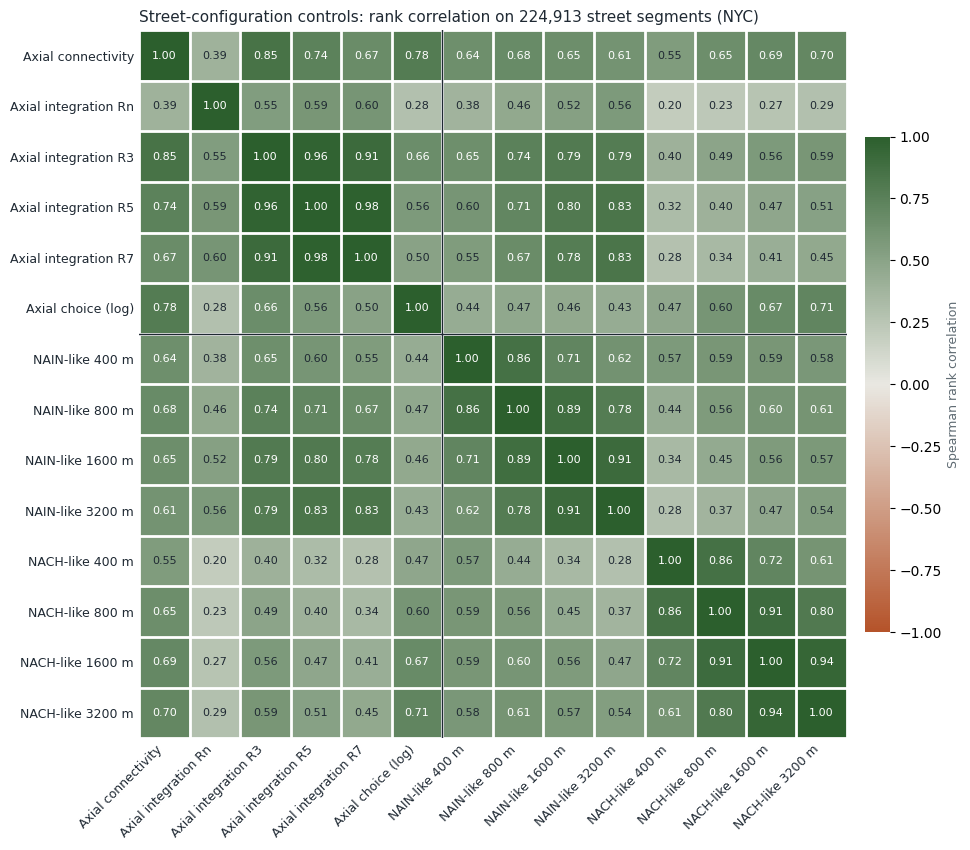

axial × angular: strongest pairs
ax_int_r7  nain_3200    0.830
ax_int_r5  nain_3200    0.830
           nain_1600    0.800
ax_int_r3  nain_1600    0.790
           nain_3200    0.785
ax_int_r7  nain_1600    0.775


In [10]:
st = SEG[SEG.live & SEG.kind.isin(FRONT_KINDS)]
CORR = st[CTRL_COLS].corr(method="spearman")
CORR.round(3).to_csv(CT_DIR / "control_correlations.csv")
LABEL = {"ax_connectivity": "Axial connectivity", "ax_int_n": "Axial integration Rn", "ax_int_r3": "Axial integration R3",
         "ax_int_r5": "Axial integration R5", "ax_int_r7": "Axial integration R7", "ax_choice_log": "Axial choice (log)",
         **{f"nain_{r}": f"NAIN-like {r} m" for r in ANG_RADII}, **{f"nach_{r}": f"NACH-like {r} m" for r in ANG_RADII}}
INK, MUTED_INK, GRID = "#1F2933", "#5F6B73", "#E1E0D9"
DIV = LinearSegmentedColormap.from_list("div", ["#B5532A", "#E9E8E2", "#2C5F2D"])   # 음(주황) – 중립 회색 – 양(녹색)
fig, ax = plt.subplots(figsize=(10.5, 8.6))
im = ax.imshow(CORR.values, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR)), [LABEL[c] for c in CORR.columns], rotation=45, ha="right", fontsize=9, color=INK)
ax.set_yticks(range(len(CORR)), [LABEL[c] for c in CORR.index], fontsize=9, color=INK)
for i in range(len(CORR)):
    for j in range(len(CORR)):
        v = CORR.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.6 else INK)
ax.set_xticks(np.arange(-0.5, len(CORR)), minor=True)
ax.set_yticks(np.arange(-0.5, len(CORR)), minor=True)
ax.grid(which="minor", color="white", lw=2)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.axhline(len(AX_COLS) - 0.5, color=INK, lw=1)
ax.axvline(len(AX_COLS) - 0.5, color=INK, lw=1)
cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("Spearman rank correlation", color=MUTED_INK, fontsize=9)
cb.outline.set_visible(False)
ax.set_title(f"Street-configuration controls: rank correlation on {len(st):,} street segments ({STUDY_AREA})", fontsize=11, color=INK, loc="left")
fig.tight_layout()
fig.savefig(CT_DIR / "control_correlations.png", dpi=160, facecolor="white")
plt.show()
block = CORR.loc[AX_COLS, ANG_COLS]
print("axial × angular: strongest pairs")
print(block.stack().sort_values(ascending=False).head(6).round(3).to_string())

## 14-8. 군집 영역·공원 영역 단위 집계
100 m 상업 영역 안에 있는 **가로(street) 세그먼트**의 값을 영역 안 길이로 가중 평균한다. 밀도·다양성처럼 영역 단위 결과변수의 통제변수로 쓴다.
- `*_mean`: 길이 가중 평균, `*_max`: 영역 안 최댓값
- `top10_*_share`: 영역 안 가로 길이 중, 도시 전체 상위 10%(길이 기준) 가로가 차지하는 비율
- 영역에 가로 세그먼트가 없으면 모든 종류의 세그먼트로 계산하고 `basis = "all"`로 표시한다.

공원 단위 표도 만든다(공원마다 100 m 영역). 정의 간 비교용 공원 단위 모형에서 쓴다.

In [11]:
SEG_G = SEG.geometry.values
IS_FRONT = SEG.kind.isin(FRONT_KINDS).values
TOP = {}
for c in ["nach_1600", "ax_int_n"]:
    s = SEG.loc[SEG.live & IS_FRONT, [c, "length"]].dropna().sort_values(c, ascending=False)
    TOP[c] = s[c].values[np.searchsorted(s.length.cumsum().values, 0.10 * s.length.sum())]


def ring_controls(rings):
    """rings: id를 인덱스로 하는 GeoSeries(CRS = 프로젝트 좌표계)"""
    geoms = shapely.make_valid(np.asarray(rings.values))
    ri, si = SEG.sindex.query(geoms, predicate="intersects")
    w = shapely.length(shapely.intersection(SEG_G[si], geoms[ri]))
    d = pd.DataFrame({"ring": ri, "seg": si, "w": w, "front": IS_FRONT[si]})
    d = d[d.w > 0]
    has_front = d.groupby("ring").front.any()
    d = d[d.front | ~d.ring.map(has_front)]
    X = SEG[CTRL_COLS].values[d.seg.values]
    out = pd.DataFrame(index=np.arange(len(rings)))
    g = d.ring.values
    for k, c in enumerate(CTRL_COLS):
        ok = np.isfinite(X[:, k])
        num = np.bincount(g[ok], weights=(X[ok, k] * d.w.values[ok]), minlength=len(rings))
        den = np.bincount(g[ok], weights=d.w.values[ok], minlength=len(rings))
        out[c + "_mean"] = np.where(den > 0, num / np.maximum(den, 1e-12), np.nan)
        out[c + "_max"] = pd.Series(X[ok, k]).groupby(g[ok]).max().reindex(out.index).values
    tot = np.bincount(g, weights=d.w.values, minlength=len(rings))
    for c, thr in TOP.items():
        hit = SEG[c].values[d.seg.values] >= thr
        out[f"top10_{c}_share"] = np.where(tot > 0, np.bincount(g[hit], weights=d.w.values[hit], minlength=len(rings)) / np.maximum(tot, 1e-12), np.nan)
    out["street_len_m"] = tot
    out["n_segments"] = np.bincount(g, minlength=len(rings))
    out["basis"] = np.where(out.n_segments == 0, "none", np.where(has_front.reindex(out.index, fill_value=False).values, "street", "all"))
    out.index = rings.index
    return out


CL_DIR = OUT_DIR / "clusters"
if CL_DIR.exists():
    frames = []
    for dname in ["D", "N1", "N2", "N3"]:
        cl = gpd.read_file(CL_DIR / f"clusters_{dname}.geojson").to_crs(CRS).set_index("cluster_id")
        rc = ring_controls(cl.geometry)
        rc.insert(0, "definition", dname)
        frames.append(rc.reset_index())
    CLUSTER_CTRL = pd.concat(frames, ignore_index=True)
    CLUSTER_CTRL.to_csv(CT_DIR / "cluster_street_controls.csv", index=False)
    memb = pd.read_csv(CL_DIR / "park_cluster_membership.csv")
    all_parks_union = gpd.read_file(PARKS_PATH).to_crs(CRS).geometry.make_valid().union_all()
    pring = parks.loc[memb.park_id].geometry.buffer(COMMERCIAL_BUFFER).difference(all_parks_union)
    PARK_CTRL = ring_controls(pring)
    PARK_CTRL.index.name = "park_id"
    PARK_CTRL.to_csv(CT_DIR / "park_street_controls.csv")
    assert CLUSTER_CTRL.groupby("definition").cluster_id.nunique().sum() == len(CLUSTER_CTRL)
    assert len(PARK_CTRL) == len(memb)
    print(CLUSTER_CTRL.groupby("definition").basis.value_counts().unstack(fill_value=0))
    print("parks:", PARK_CTRL.basis.value_counts().to_dict())
    display(CLUSTER_CTRL.groupby("definition")[["ax_int_n_mean", "ax_int_r3_mean", "nain_800_mean", "nach_1600_mean", "top10_nach_1600_share"]].median().round(3))
else:
    print("군집 영역(STEP 13) 없음 → 집계 건너뜀")

basis       all  none  street
definition                   
D             5     6    1121
N1            5     6    1208
N2            5     6    1163
N3            5     6    1980
parks: {'street': 2046, 'none': 6, 'all': 5}


,ax_int_n_mean,ax_int_r3_mean,nain_800_mean,nach_1600_mean,top10_nach_1600_share
definition,,,,,
D,0.592,3.285,1.067,1.100,0.064
N1,0.585,3.152,1.040,1.092,0.049
N2,0.590,3.252,1.059,1.097,0.052
N3,0.598,3.352,1.076,1.104,0.043


## 14-9. POI → 가로 연결 함수
Advan POI가 준비되면 이 함수로 각 상점에 접한 가로의 값을 붙인다(방문량의 POI 단위 모형용).
- 기본: 가장 가까운 가로(street) 세그먼트의 값
- `corner_radius`를 주면 그 반경 안 가로 세그먼트 중 열별 최댓값을 쓴다. 모퉁이 가게가 더 큰 길의 값을 받게 하는 선택지다.

In [12]:
FRONT = SEG[SEG.kind.isin(FRONT_KINDS)].reset_index(drop=True)


def attach_points(points, max_dist=50.0, corner_radius=None):
    """points: GeoSeries(점). 반환: 점마다 seg_id, 거리(m), 통제변수. max_dist 밖이면 NaN"""
    pts = gpd.GeoSeries(points).to_crs(CRS)
    pi, si = FRONT.sindex.nearest(pts.values, max_distance=max_dist, return_all=False)
    out = pd.DataFrame(index=pts.index, columns=["seg_id", "dist_m"] + CTRL_COLS, dtype=object)
    out.loc[pts.index[pi], "seg_id"] = FRONT.seg_id.values[si]
    out.loc[pts.index[pi], "dist_m"] = shapely.distance(pts.values[pi], FRONT.geometry.values[si])
    out.loc[pts.index[pi], CTRL_COLS] = FRONT[CTRL_COLS].values[si]
    if corner_radius:
        qi, sj = FRONT.sindex.query(pts.values, predicate="dwithin", distance=corner_radius)
        mx = pd.DataFrame(FRONT[CTRL_COLS].values[sj], columns=CTRL_COLS).groupby(qi).max()
        out.loc[pts.index[mx.index], CTRL_COLS] = mx.values
    return out.astype({c: float for c in ["dist_m"] + CTRL_COLS})


# 자체 점검: 가로 세그먼트 중점에서 옆으로 8 m 떨어진 점은 원래 세그먼트(또는 같은 선)에 붙어야 한다
rng = np.random.default_rng(0)
smp = FRONT[(FRONT.length > 60) & FRONT.live].sample(2000, random_state=0)
mid = shapely.line_interpolate_point(smp.geometry.values, 0.5, normalized=True)
nxt = shapely.line_interpolate_point(smp.geometry.values, 0.5 + 1 / smp.length.values * 1.0, normalized=True)
dx, dy = shapely.get_x(nxt) - shapely.get_x(mid), shapely.get_y(nxt) - shapely.get_y(mid)
nrm = np.maximum(np.hypot(dx, dy), 1e-9)
test_pts = gpd.GeoSeries(shapely.points(shapely.get_x(mid) - dy / nrm * 8, shapely.get_y(mid) + dx / nrm * 8), crs=CRS)
got = attach_points(test_pts)
same_seg = (got.seg_id.values == smp.seg_id.values).mean()
same_line = (FRONT.set_index("seg_id").ax_line.reindex(got.seg_id.values).values == smp.ax_line.values).mean()
print(f"self-test on {len(smp):,} points: same segment {same_seg:.1%}, same axial line {same_line:.1%}, median distance {got.dist_m.median():.1f} m")
assert same_line > 0.9
attach_points(test_pts.iloc[:3], corner_radius=25).round(3)

self-test on 2,000 points: same segment 91.9%, same axial line 91.9%, median distance 8.0 m


,seg_id,dist_m,ax_connectivity,ax_int_n,ax_int_r3,ax_int_r5,ax_int_r7,ax_choice_log,nain_400,nain_800,nain_1600,nain_3200,nach_400,nach_800,nach_1600,nach_3200
0,42981195_8679609812_0,8.000,1.0,0.628,1.738,1.756,1.594,0.000,0.681,0.697,0.821,0.862,0.000,0.000,0.000,0.000
1,42847327_12248176742_0,3.731,10.0,0.535,3.247,2.451,1.990,7.813,1.063,1.071,1.053,1.083,1.061,1.137,1.185,1.181
2,6888578244_8459935168_0,8.000,11.0,0.502,3.008,2.069,1.700,6.741,0.809,0.955,0.959,0.921,1.096,1.245,1.215,1.308


## 14-10. 지도: axial Integration
색은 한 색상(녹색)의 옅음→짙음으로 크기를 나타낸다. 짙을수록 통합도가 높다(선 길이 기준 10분위).

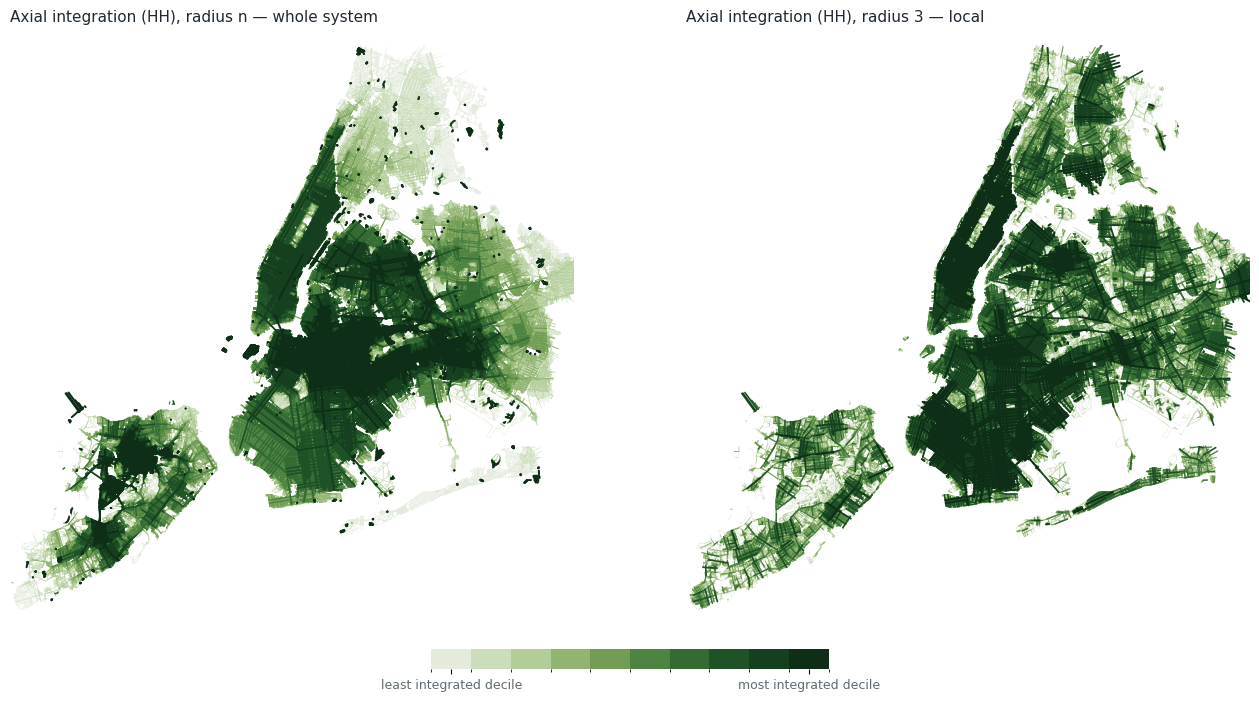

In [13]:
SEQ = LinearSegmentedColormap.from_list("seq", ["#E4EBDD", "#B9D1A0", "#7FA65A", "#3F7A3A", "#1B4D25", "#0E2E17"])
al = lines.join(MEAS[AXIAL_TOL][["int_n", "int_r3", "connectivity", "choice_log"]])
al_geom = CHORD
AREA_B = AREA.buffer(200)
shapely.prepare(AREA_B)
in_area = shapely.intersects(al_geom, AREA_B)


def axial_map(ax, col, window=None, lw=0.35, title=""):
    m = in_area & np.isfinite(al[col].values)
    if window is not None:
        m &= shapely.intersects(al_geom, window)
    v, w = al[col].values[m], al.chord_m.values[m]
    order = np.argsort(v)
    cuts = v[order][np.searchsorted(np.cumsum(w[order]) / w.sum(), np.arange(0.1, 1.0, 0.1))]   # 길이 기준 10분위
    cls = np.digitize(v, cuts)
    seg_xy = np.stack([P0[m], P1[m]], axis=1)[order]
    lc = LineCollection(seg_xy, colors=SEQ(cls[order] / 9), linewidths=lw + 0.12 * cls[order] * (lw / 0.35), capstyle="round")
    ax.add_collection(lc)
    b = (window if window is not None else AREA).bounds
    ax.set_xlim(b[0], b[2])
    ax.set_ylim(b[1], b[3])
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title, fontsize=11, color=INK, loc="left")
    return cuts


fig, axes = plt.subplots(1, 2, figsize=(16, 8.6))
c1 = axial_map(axes[0], "int_n", title="Axial integration (HH), radius n — whole system")
c2 = axial_map(axes[1], "int_r3", title="Axial integration (HH), radius 3 — local")
sm = plt.cm.ScalarMappable(cmap=SEQ, norm=BoundaryNorm(np.arange(11), SEQ.N))
cb = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.03, pad=0.02, ticks=[0.5, 9.5])
cb.ax.set_xticklabels(["least integrated decile", "most integrated decile"], color=MUTED_INK, fontsize=9)
cb.outline.set_visible(False)
fig.savefig(CT_DIR / "map_axial_integration.png", dpi=170, facecolor="white", bbox_inches="tight")
plt.show()

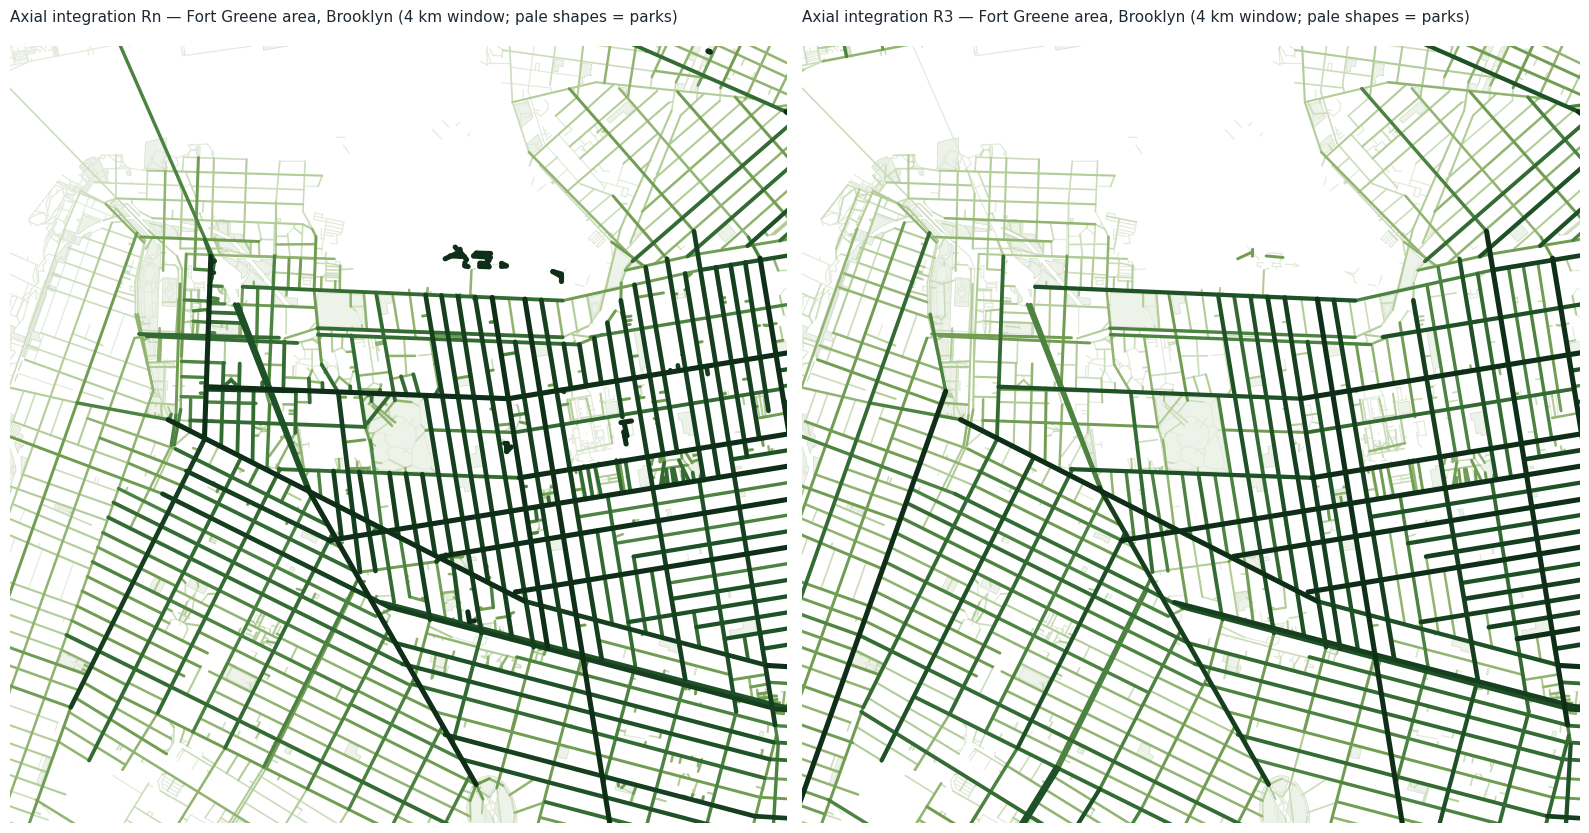

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8.2))
pk = parks[parks.intersects(PILOT_WIN)]
for ax, col, ttl in [(axes[0], "int_n", "Axial integration Rn"), (axes[1], "int_r3", "Axial integration R3")]:
    pk.plot(ax=ax, color="#EEF3EA", edgecolor="#C9D6C0", lw=0.4, zorder=0)
    axial_map(ax, col, window=PILOT_WIN, lw=0.9, title=f"{ttl} — Fort Greene area, Brooklyn (4 km window; pale shapes = parks)")
fig.tight_layout()
fig.savefig(CT_DIR / "map_axial_pilot.png", dpi=170, facecolor="white", bbox_inches="tight")
plt.show()

## 14-11. 저장과 데이터 사전

In [15]:
out_lines = gpd.GeoDataFrame(al.drop(columns=["x0", "y0", "x1", "y1"]).join(
    MEAS[AXIAL_TOL][["system", "node_count", "md_n", "int_r5", "int_r7", "choice", "choice_norm"]]), geometry=al_geom, crs=CRS)[in_area]
out_lines.to_file(CT_DIR / "axial_lines.gpkg", driver="GPKG", layer="axial_lines")
SEG.to_parquet(CT_DIR / "segment_controls.parquet")
readme = f"""# 가로 구조 통제변수 (STEP 14)

회귀에서 "큰길 효과"를 통제하기 위한 가로 값이다. 공원 네트워크 정의(D·N1·N2·N3)에는 쓰지 않는다.

## 파일
| 파일 | 단위 | 내용 |
|---|---|---|
| `axial_lines.gpkg` | axial line {int(in_area.sum()):,}개 | 선 도형과 axial 지표 (EPSG:{CRS}) |
| `segment_controls.parquet` | 가로 세그먼트 {len(SEG):,}개 | 세그먼트별 axial·angular 값 (GeoParquet) |
| `cluster_street_controls.csv` | 정의 × 군집 | 군집 100 m 상업 영역 안 가로 값의 길이 가중 평균·최댓값 |
| `park_street_controls.csv` | 공원 | 공원별 100 m 영역 안 가로 값 |
| `control_correlations.csv` / `.png` | | 통제변수 간 Spearman 상관 |
| `axial_validation.csv` | | alcyon(depthmapX 엔진)과의 대조 결과 |
| `axial_tolerance_sensitivity.csv` | | 허용 횡편차 5·10·15 m 민감도 |
| `map_axial_integration.png`, `map_axial_pilot.png` | | Integration 지도 |
| `alcyon_pilot.R` | | 검증에 쓴 R 스크립트 |

## 변수
| 변수 | 뜻 |
|---|---|
| `ax_line` | 세그먼트가 속한 axial line id (가장 길게 겹치는 선) |
| `ax_share` | 세그먼트 길이 중 그 선에 속한 비율 |
| `ax_connectivity` | 그 선과 교차하는 선의 수 |
| `ax_int_n` | Integration(HH), 반경 n (연결된 시스템 전체) |
| `ax_int_r3`, `ax_int_r5`, `ax_int_r7` | Integration(HH), 위상 반경 3·5·7 단계 |
| `ax_choice`, `ax_choice_norm`, `ax_choice_log` | Choice(순서쌍 기준), 정규화 값, log10(choice + 1) |
| `ax_system`, `ax_node_count` | 연결된 시스템 번호와 그 시스템의 선 개수 |
| `nain_{{r}}` | NAIN 유사 = density^1.2 / farness, 반경 r m (Cityseer 각도) |
| `nach_{{r}}` | NACH 유사 = log(choice + 1) / log(farness + 3), 반경 r m (Cityseer 각도) |
| `*_mean`, `*_max` | 영역 안 가로 세그먼트의 길이 가중 평균, 최댓값 |
| `top10_nach_1600_share`, `top10_ax_int_n_share` | 영역 안 가로 길이 중 도시 상위 10% 가로의 비율 |
| `street_len_m`, `n_segments`, `basis` | 집계에 쓴 길이·세그먼트 수, 기준(`street` = 가로만, `all` = 가로가 없어 전체 사용) |

## Axial line 만드는 법
- 가로 중심선(C 망)에서 교차점마다 가장 곧게 이어지는 세그먼트를 잇고(편차 < {AXIAL_DEFL}°), Douglas–Peucker로 허용 횡편차 {AXIAL_TOL} m 안의 직선 조각으로 나눈다.
- 두 선은 보행망의 같은 교차점을 지나면 연결된다.
- 지표는 Hillier & Hanson(1984) 정의다. 같은 연결 그래프에서 alcyon과 Connectivity·Mean Depth·Integration(HH)이 일치한다(`axial_validation.csv`).

## 쓸 때 주의
- axial과 angular 값은 서로 상관이 있다(`control_correlations.csv`). 한 모형에는 계열마다 한두 개만 넣는다.
- N2 군집의 "큰길 비율" 속성은 NACH에서 만든 것이므로 `nach_*`와 같이 넣지 않는다.
- 보행망이 끊긴 시스템(스태튼아일랜드 등)은 `ax_int_n`이 시스템별로 계산된다. 보로 고정효과와 함께 쓴다.
- POI 단위 값은 노트북의 `attach_points()`로 붙인다.
"""
(CT_DIR / "README.md").write_text(readme)
print("saved to", CT_DIR.relative_to(ROOT))
for f in sorted(CT_DIR.iterdir()):
    print(f"  {f.name:38s} {f.stat().st_size / 1e6:8.1f} MB")

INFO:pyogrio._io:Created 135,773 records


saved to outputs/NYC/controls
  README.md                                   0.0 MB
  alcyon_pilot.R                              0.0 MB
  axial_lines.gpkg                           35.9 MB
  axial_tolerance_sensitivity.csv             0.0 MB
  axial_validation.csv                        0.0 MB
  cluster_street_controls.csv                 3.1 MB
  control_correlations.csv                    0.0 MB
  control_correlations.png                    0.3 MB
  map_axial_integration.png                   1.3 MB
  map_axial_pilot.png                         1.9 MB
  park_street_controls.csv                    1.2 MB
  segment_controls.parquet                   62.5 MB
